In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

In [55]:
df = pd.read_csv("../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv")

In [56]:
print("Shape:", df.shape)
print("Missing values total:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant columns:", constant_cols)

print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nLabel percentages:")
print(df["label"].value_counts(normalize=True) * 100)

Shape: (235795, 56)
Missing values total: 0
Duplicate rows: 0
Constant columns: []

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Label percentages:
label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


In [57]:
text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print("\nText columns:", text_cols)


Text columns: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']


In [58]:
df_baseline = df.drop(columns=text_cols)

X = df_baseline.drop(columns=["label"])
y = df_baseline["label"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature dtypes:")
print(X.dtypes.value_counts())


X shape: (235795, 50)
y shape: (235795,)

Feature dtypes:
int64      40
float64    10
Name: count, dtype: int64


In [59]:
df_baseline.to_csv("../data/processed/dataset_baseline_v1.csv", index=False)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Train/Test shapes:
X_train: (188636, 50)
X_test : (47159, 50)
y_train: (188636,)
y_test : (47159,)


In [61]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=42))
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

In [62]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

In [63]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("\nBaseline Model Evaluation")
print("-" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"PR AUC    : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Baseline Model Evaluation
----------------------------------------
Accuracy  : 0.9999
Precision : 0.9998
Recall    : 1.0000
F1 Score  : 0.9999
ROC AUC   : 1.0000
PR AUC    : 1.0000

Confusion Matrix:
[[20183     6]
 [    0 26970]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999     20189
           1     0.9998    1.0000    0.9999     26970

    accuracy                         0.9999     47159
   macro avg     0.9999    0.9999    0.9999     47159
weighted avg     0.9999    0.9999    0.9999     47159



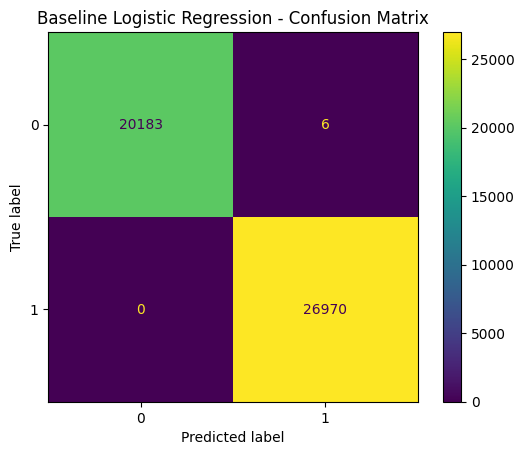

In [67]:
ConfusionMatrixDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test,
    values_format="d",
    cmap="viridis"
)
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

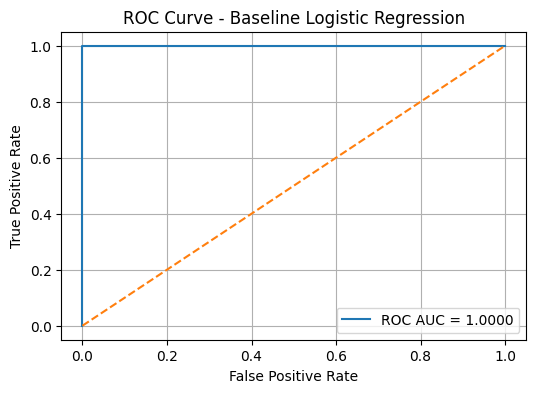

In [65]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

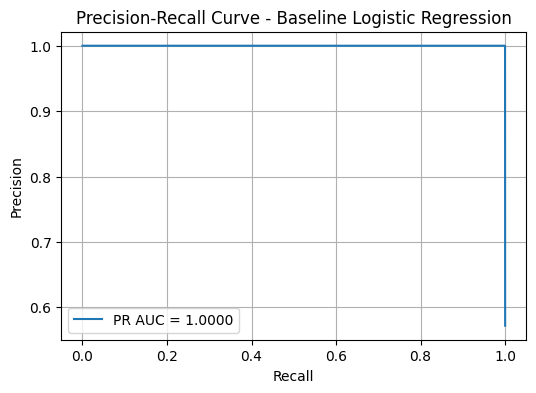

In [66]:
precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Baseline Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

Baseline Conclusion
Baseline model: Logistic Regression with StandardScaler
Test accuracy is extremely high
Confusion matrix shows only 6 false positives and 0 false negatives
This result is promising, but it requires validation to check for possible leakage or overly informative features
Next step: validation and leakage check